<span style="color:sienna">

## **streamflow eda**

</span>

des plaines river at riverside (usgs 05532500): daily mean streamflow + open-meteo weather. no modeling yet - just the data and its drift/quality hooks.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sienna, olive, steel, gray = "#a0522d", "#808000", "#4682b4", "#b0b0b0"
plt.rcParams["axes.facecolor"] = "#faf7f2"
plt.rcParams["figure.facecolor"] = "#faf7f2"

df = pd.read_parquet("../data/raw/streamflow.parquet")
df["date"] = pd.to_datetime(df["date"])
df.shape

(30148, 8)

### overview
~82 years daily, no missing streamflow or weather.

In [9]:
print("span:", df.date.min().date(), "->", df.date.max().date())
print("rows:", len(df))
print("streamflow nulls:", df.streamflow_cfs.isna().sum(), "| weather nulls:", df.precip_mm.isna().sum())
df.head(3)

span: 1944-01-01 -> 2026-07-18
rows: 30148
streamflow nulls: 0 | weather nulls: 0


,date,streamflow_cfs,approval_status,qualifier,last_modified,precip_mm,tmax_c,tmin_c
0,1944-01-01,31.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,3.4,-5.6
1,1944-01-02,45.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,2.9,-4.2
2,1944-01-03,33.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,3.3,-3.2


### target
0 to 10,700 cfs, heavily right-skewed -> model in log space. median ~365, floods 20-30x that.

min         0.00000
50%       365.00000
mean      640.69126
max     10700.00000
Name: streamflow_cfs, dtype: float64


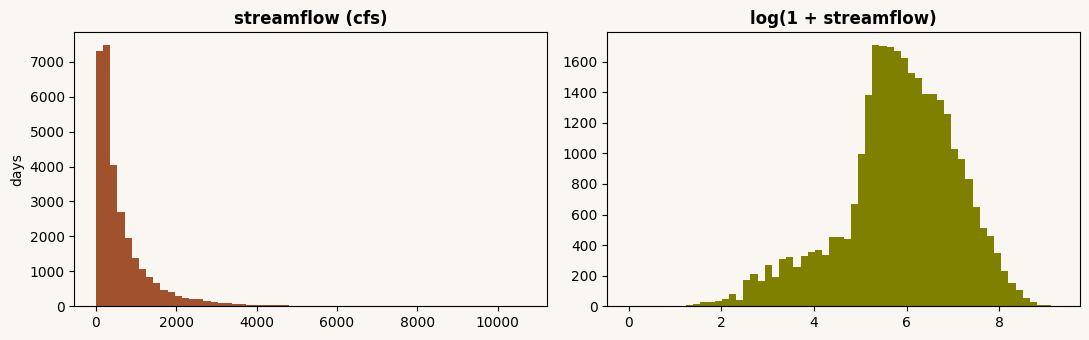

In [10]:
print(df.streamflow_cfs.describe()[["min","50%","mean","max"]])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df.streamflow_cfs, bins=60, color=sienna)
ax[0].set_title("streamflow (cfs)", weight="bold"); ax[0].set_ylabel("days")
ax[1].hist(np.log1p(df.streamflow_cfs), bins=60, color=olive)
ax[1].set_title("log(1 + streamflow)", weight="bold")
plt.tight_layout(); plt.show()

### hydrograph

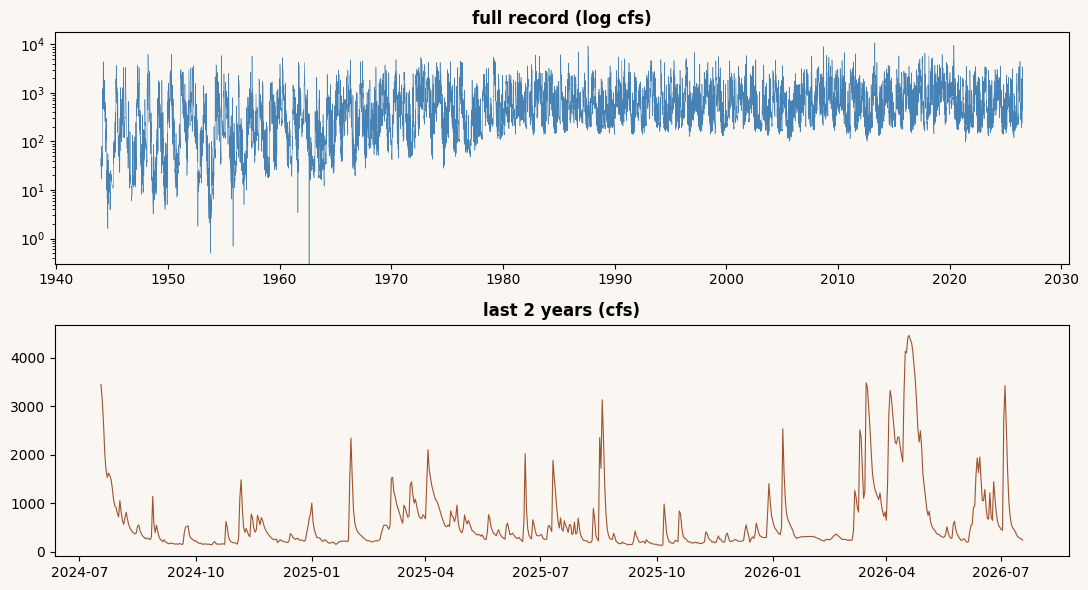

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6))
ax[0].plot(df.date, df.streamflow_cfs, color=steel, lw=0.4)
ax[0].set_yscale("log"); ax[0].set_title("full record (log cfs)", weight="bold")
recent = df[df.date >= df.date.max() - pd.Timedelta(days=730)]
ax[1].plot(recent.date, recent.streamflow_cfs, color=sienna, lw=0.8)
ax[1].set_title("last 2 years (cfs)", weight="bold")
plt.tight_layout(); plt.show()

### rain -> flow
the learnable signal. july 2026 flood: 17-21mm rain, streamflow 455 -> 3420 cfs.

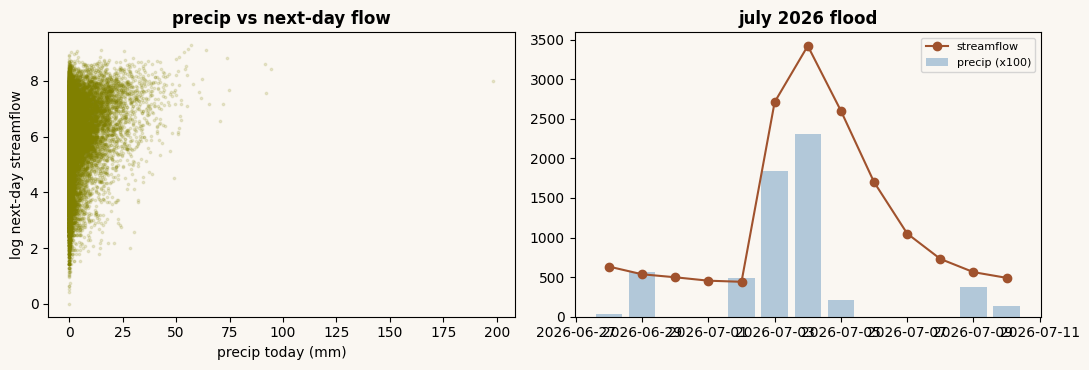

In [12]:
d = df.copy()
d["next_streamflow"] = d.streamflow_cfs.shift(-1)   # next-day target
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].scatter(d.precip_mm, np.log1p(d.next_streamflow), s=3, alpha=0.15, color=olive)
ax[0].set_xlabel("precip today (mm)"); ax[0].set_ylabel("log next-day streamflow")
ax[0].set_title("precip vs next-day flow", weight="bold")
flood = d[(d.date >= "2026-06-28") & (d.date <= "2026-07-10")]
ax[1].plot(flood.date, flood.streamflow_cfs, color=sienna, marker="o", label="streamflow")
ax[1].bar(flood.date, flood.precip_mm * 100, color=steel, alpha=0.4, label="precip (x100)")
ax[1].set_title("july 2026 flood", weight="bold"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### seasonality
spring high, late-summer low - natural concept drift for monitoring.

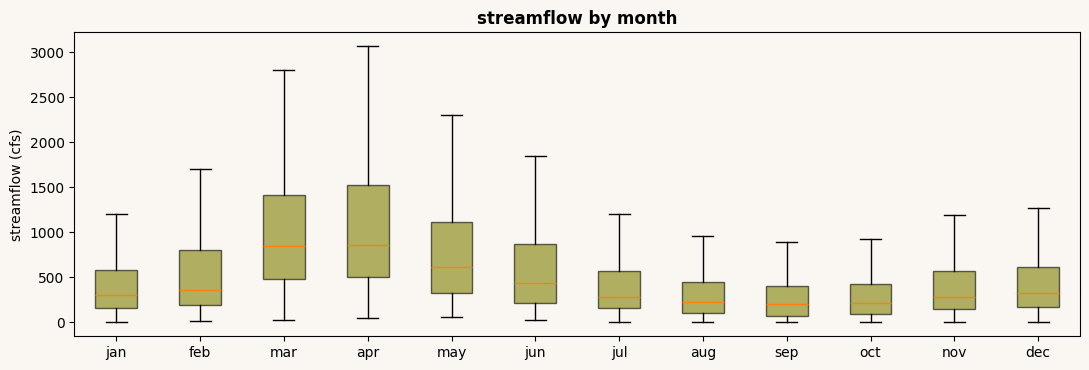

In [13]:
d["month"] = d.date.dt.month
monthly = [d[d.month == m].streamflow_cfs.values for m in range(1, 13)]
fig, ax = plt.subplots(figsize=(11, 3.8))
bp = ax.boxplot(monthly, showfliers=False, patch_artist=True)
for box in bp["boxes"]: box.set(facecolor=olive, alpha=0.6)
ax.set_xticklabels(["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"])
ax.set_ylabel("streamflow (cfs)"); ax.set_title("streamflow by month", weight="bold")
plt.tight_layout(); plt.show()

### quality + drift hooks
all real, no simulation: `provisional` tail (usgs revises for months), `estimated`/`ice` winter qualifiers, `revised` = values usgs already changed.

In [14]:
print("approval:", df.approval_status.value_counts().to_dict())
print("qualifier:", df.qualifier.value_counts(dropna=False).to_dict())
est = df[df.qualifier.notna() & df.qualifier.str.contains("ESTIMATED|ICE")]
print("estimated/ice by month:", est.date.dt.month.value_counts().sort_index().to_dict())
prov = df[df.approval_status == "Provisional"]
print("provisional tail:", prov.date.min().date(), "->", prov.date.max().date(), f"({len(prov)} rows)")

approval: {'Approved': 30102, 'Provisional': 46}
qualifier: {None: 29173, 'ESTIMATED': 811, 'REVISED': 150, 'ESTIMATED,REVISED': 12, 'ICE': 2}
estimated/ice by month: {1: 367, 2: 241, 3: 12, 5: 1, 6: 8, 7: 3, 8: 1, 9: 27, 10: 10, 11: 17, 12: 138}
provisional tail: 2026-06-01 -> 2026-07-18 (46 rows)


### takeaways
- log space, persistence baseline, nse + log-rmse
- features: streamflow lags/rolling, precip + temp, day-of-year
- monitoring: seasonal regimes, floods, winter estimates, provisional revisions
- next: `features.py`, then train + mlflow